In [20]:
import pandas as pd

In [21]:
import numpy as np

In [22]:
import matplotlib.pyplot as plt

In [23]:
import seaborn as sns

In [24]:
from sklearn.preprocessing import MinMaxScaler

In [25]:
%matplotlib inline

In [26]:
df = pd.read_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/external/3. Feature Engineering/Ft Engineering(One-Hot).csv")

In [27]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Vicarious Visions,Developer_Visual Concepts,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent,Game Quality,Game Quality Encoded
0,Spider-Man: Mysterio's Menace,7.10189,0.61,0.43,0.00,0.16,0.01,2001,False,False,...,True,False,2000,0.704918,0.262295,0.000000,0.016393,0,High,2
1,Tomb Raider Chronicles,7.10189,0.61,0.34,0.00,0.23,0.04,2000,False,False,...,False,False,2000,0.557377,0.377049,0.000000,0.065574,0,High,2
2,Tony Hawk: RIDE,4.50000,0.61,0.38,0.00,0.15,0.08,2009,False,False,...,False,False,2000,0.622951,0.245902,0.000000,0.131148,0,Medium,1
3,Advance Wars: Days of Ruin,8.40000,0.61,0.43,0.00,0.13,0.05,2008,False,False,...,False,False,2000,0.704918,0.213115,0.000000,0.081967,0,High,2
4,New Play Control! Pikmin 2,8.70000,0.61,0.11,0.34,0.13,0.02,2012,False,False,...,False,False,2010,0.180328,0.213115,0.557377,0.032787,0,High,2


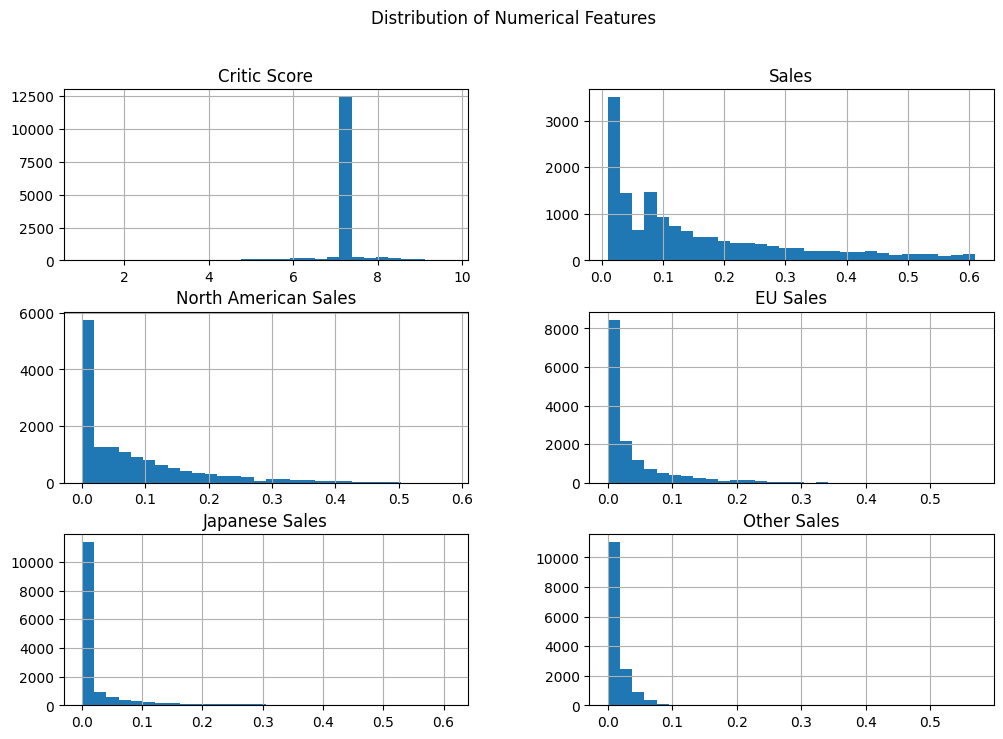

In [28]:
# Histogram of numerical columns

df[["Critic Score","Sales","North American Sales",
    "EU Sales","Japanese Sales","Other Sales"]].hist(figsize=(12,8), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()

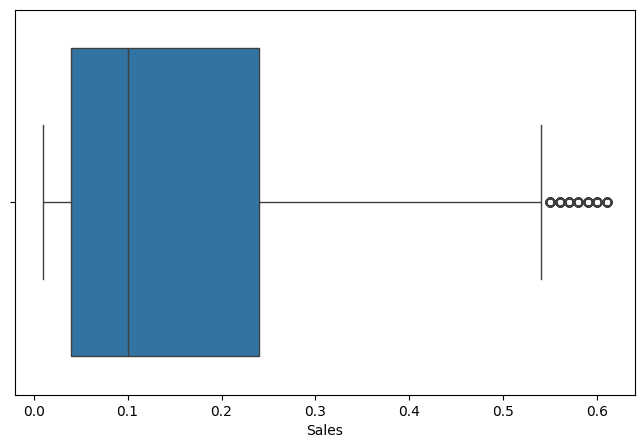

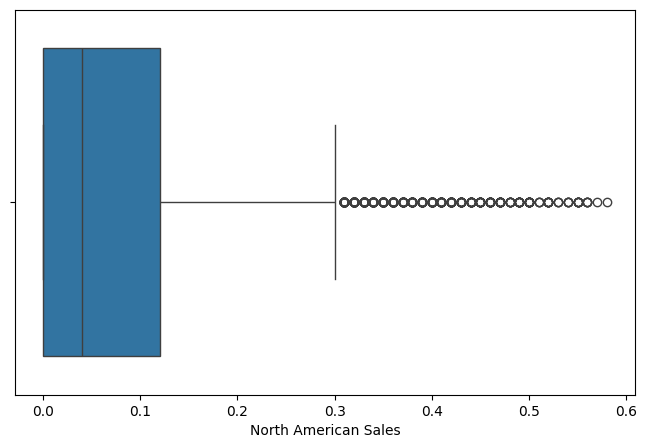

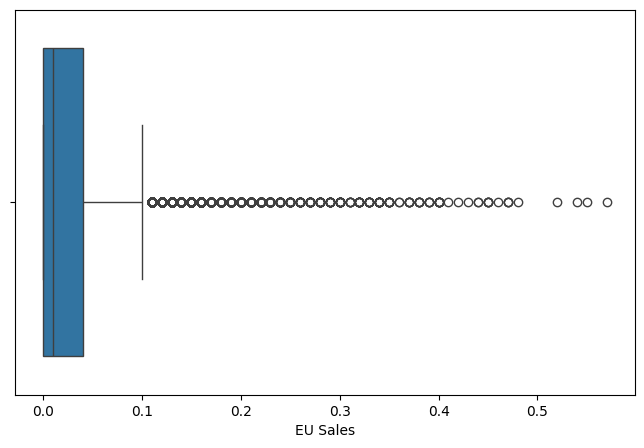

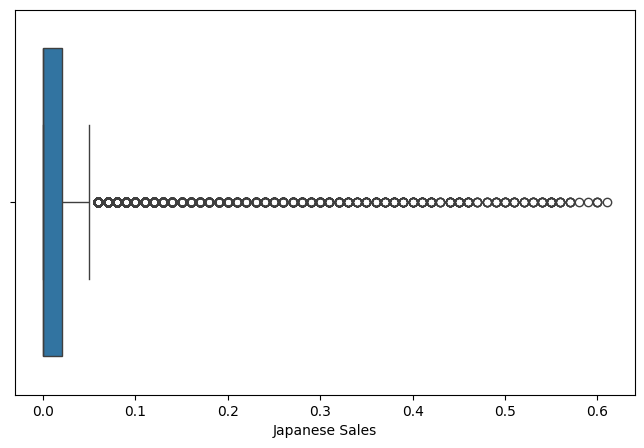

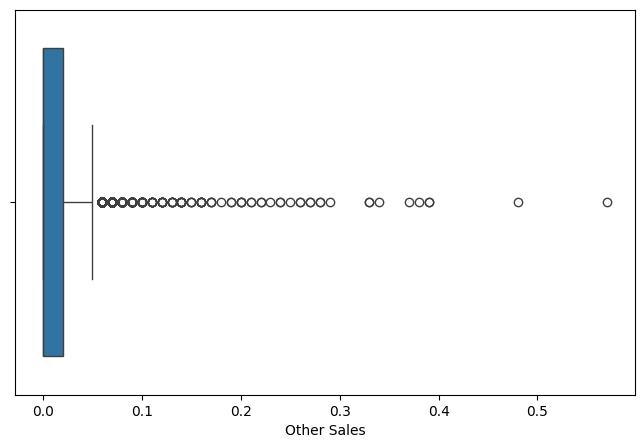

In [29]:
#Boxplot For Numerical Values 

for col in ["Sales","North American Sales","EU Sales","Japanese Sales","Other Sales"]:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[col])

In [30]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Vicarious Visions,Developer_Visual Concepts,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent,Game Quality,Game Quality Encoded
0,Spider-Man: Mysterio's Menace,7.10189,0.61,0.43,0.00,0.16,0.01,2001,False,False,...,True,False,2000,0.704918,0.262295,0.000000,0.016393,0,High,2
1,Tomb Raider Chronicles,7.10189,0.61,0.34,0.00,0.23,0.04,2000,False,False,...,False,False,2000,0.557377,0.377049,0.000000,0.065574,0,High,2
2,Tony Hawk: RIDE,4.50000,0.61,0.38,0.00,0.15,0.08,2009,False,False,...,False,False,2000,0.622951,0.245902,0.000000,0.131148,0,Medium,1
3,Advance Wars: Days of Ruin,8.40000,0.61,0.43,0.00,0.13,0.05,2008,False,False,...,False,False,2000,0.704918,0.213115,0.000000,0.081967,0,High,2
4,New Play Control! Pikmin 2,8.70000,0.61,0.11,0.34,0.13,0.02,2012,False,False,...,False,False,2010,0.180328,0.213115,0.557377,0.032787,0,High,2


In [31]:
df.shape # check dimentions

(14897, 133)

In [32]:
# Scale Critic Score between 0-1 ( Normalization )
scaler = MinMaxScaler()

# Scale critic score only (keep Sales as original for prediction target)
df['Critic Score'] = scaler.fit_transform(df[['Critic Score']])

In [33]:
# Scale Sales & Regional Sales between 0-1 
# Define the sales columns 
sales_cols = ['Sales', 'North American Sales', 'EU Sales', 'Japanese Sales', 'Other Sales']

scaler = MinMaxScaler()

# Fit + transform the sales columns
df[sales_cols] = scaler.fit_transform(df[sales_cols])

# Convert only boolean columns (True/False) into integers (0/1)
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

In [34]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Vicarious Visions,Developer_Visual Concepts,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent,Game Quality,Game Quality Encoded
0,Spider-Man: Mysterio's Menace,0.701367,1.0,0.741379,0.000000,0.280702,0.017544,2001,0,0,...,1,0,2000,0.704918,0.262295,0.000000,0.016393,0,High,2
1,Tomb Raider Chronicles,0.701367,1.0,0.586207,0.000000,0.403509,0.070175,2000,0,0,...,0,0,2000,0.557377,0.377049,0.000000,0.065574,0,High,2
2,Tony Hawk: RIDE,0.402299,1.0,0.655172,0.000000,0.263158,0.140351,2009,0,0,...,0,0,2000,0.622951,0.245902,0.000000,0.131148,0,Medium,1
3,Advance Wars: Days of Ruin,0.850575,1.0,0.741379,0.000000,0.228070,0.087719,2008,0,0,...,0,0,2000,0.704918,0.213115,0.000000,0.081967,0,High,2
4,New Play Control! Pikmin 2,0.885057,1.0,0.189655,0.557377,0.228070,0.035088,2012,0,0,...,0,0,2010,0.180328,0.213115,0.557377,0.032787,0,High,2


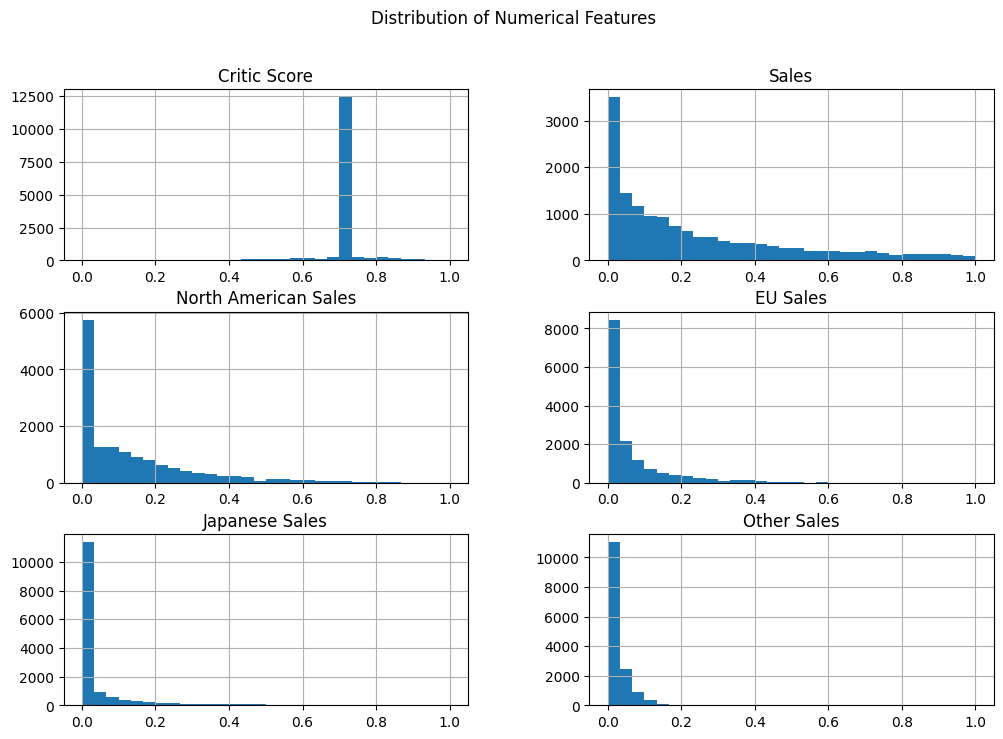

In [35]:
# Histogram of numerical columns

df[["Critic Score","Sales","North American Sales",
    "EU Sales","Japanese Sales","Other Sales"]].hist(figsize=(12,8), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()

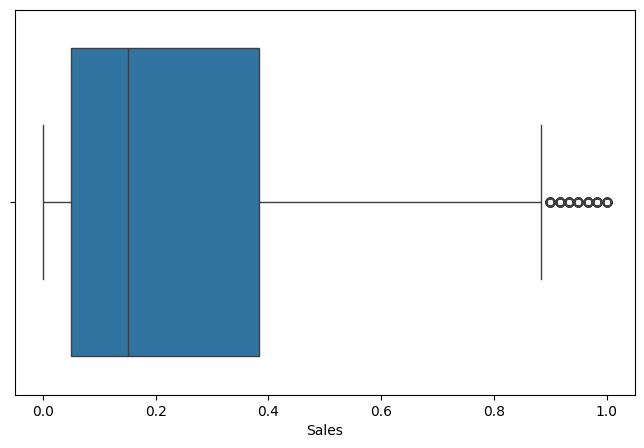

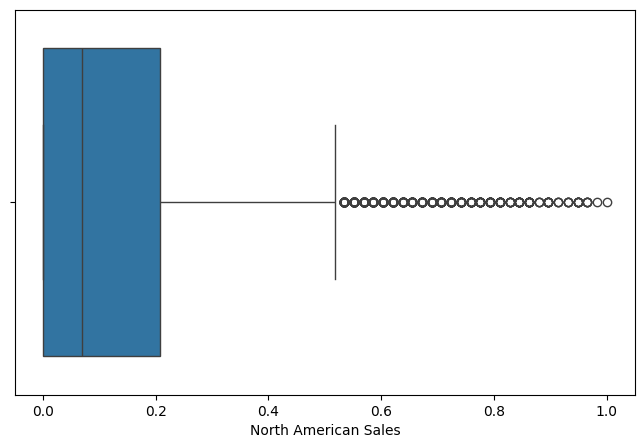

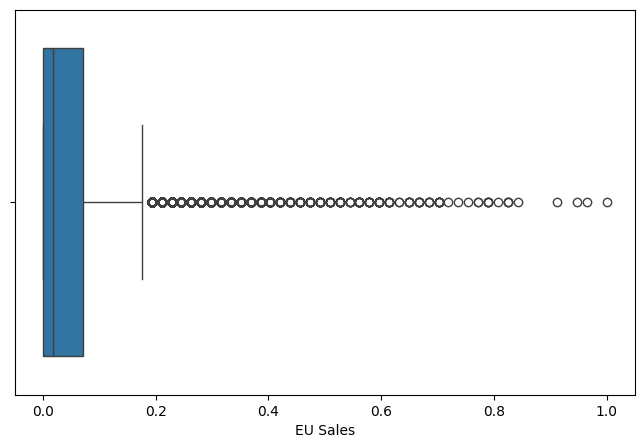

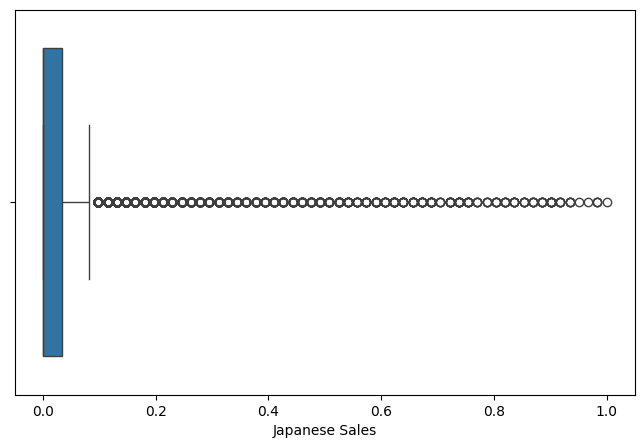

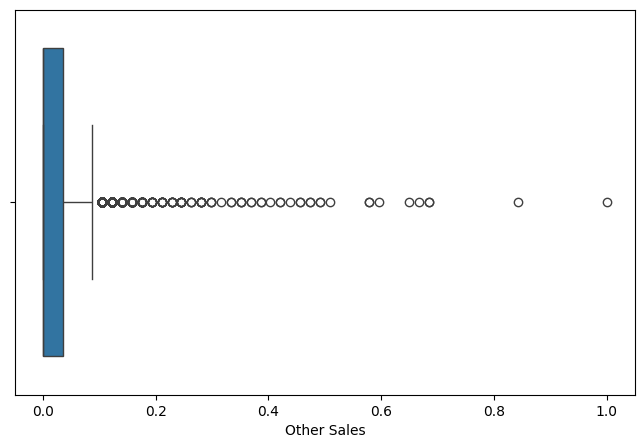

In [36]:
#Boxplot For Numerical Values 

for col in ["Sales","North American Sales","EU Sales","Japanese Sales","Other Sales"]:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[col])

In [37]:
df.to_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/external/4. Scaling/Scaling(One-Hot).csv", index=False)